<p style="color:#D9D9D9; font-size:20px;">
<b>DIGITAL LEARNING ANALYTICS:
</b>
</p>
<p style="color:#D9D9D9; font-size:17px;">
Exploring Learner Engagement, Learning Paths, and Educational Outcomes
</p>

OBJECTIVES:

1. Investigate demographic patterns in educational technology adoption
2. Analyze factors driving online course completion 
3. Compare different learning path effectiveness 
4. Study digital literacy impact on learning outcomes 

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

import plotly.express as px
import plotly.graph_objects as go

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r'C:\Users\Jayalekshmi\OneDrive\Desktop\Asquare Python\digital_learning_analytics_100k (1).csv')
df

,learner_id,age,gender,education_level,country,employment_status,prior_online_courses,digital_literacy_score,app_category,daily_app_minutes,...,content_recommendations_followed,knowledge_gaps_identified,remediation_modules_completed,time_to_mastery_hours,mastery_score,learning_efficiency_score,enrollment_date,last_activity_date,total_learning_hours,engagement_consistency
0,LRN00000001,28,Non-binary,Graduate,Australia,Student,0,8.04,Test Prep,85.0,...,47.5,2,0,21.0,44.2,21.05,2022-07-03,2022-07-16,34.2,0.527
1,LRN00000002,33,Male,Graduate,United States,Retired,7,7.07,Mathematics,54.2,...,35.9,10,2,22.4,13.0,5.80,2024-09-24,2024-10-17,34.9,0.441
2,LRN00000003,20,Male,Professional Certificate,India,Employed Full-time,6,7.79,Language Learning,53.4,...,40.6,4,0,70.5,43.2,6.13,2022-03-25,2022-04-04,37.8,0.494
3,LRN00000004,27,Female,Doctoral,South Africa,Self-employed,5,7.24,Test Prep,60.3,...,42.5,0,0,39.1,44.6,11.41,2025-01-13,2025-02-04,41.7,0.493
4,LRN00000005,50,Male,Some College,Germany,Unemployed,5,4.77,Soft Skills,31.8,...,47.4,2,0,52.6,35.1,6.67,2024-09-27,2024-11-01,36.9,0.305
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,LRN00099996,45,Female,High School,India,Employed Full-time,0,7.19,Science & Engineering,36.3,...,70.9,6,2,27.9,65.9,23.62,2022-12-23,2023-03-29,22.2,0.737
99996,LRN00099997,53,Female,Professional Certificate,India,Unemployed,5,4.80,Science & Engineering,18.0,...,79.5,6,1,46.8,48.9,10.45,2021-03-22,2021-04-29,28.3,0.436
99997,LRN00099998,39,Male,Undergraduate,South Africa,Employed Part-time,1,5.18,Science & Engineering,46.2,...,70.8,1,0,42.7,48.0,11.24,2025-09-18,2025-12-23,74.2,0.656
99998,LRN00099999,60,Male,Undergraduate,United States,Unemployed,3,5.56,Soft Skills,23.0,...,61.3,5,2,24.0,51.7,21.54,2025-09-12,2025-12-09,21.6,0.398


In [3]:
print(df.shape)
print(df.size)
print(df.columns)
print(df.ndim)
print(df.dtypes)
print(type(df))

(100000, 43)
4300000
Index(['learner_id', 'age', 'gender', 'education_level', 'country',
       'employment_status', 'prior_online_courses', 'digital_literacy_score',
       'app_category', 'daily_app_minutes', 'session_count_weekly',
       'app_completion_rate', 'in_app_quiz_score', 'gamification_engagement',
       'skill_pre_score', 'skill_post_score', 'essay_topic_category',
       'essay_word_count', 'essay_grammar_errors', 'essay_vocabulary_richness',
       'essay_coherence_score', 'human_grader_score', 'automated_score',
       'mooc_platform', 'course_category', 'course_duration_weeks',
       'video_completion_pct', 'assignment_submission_rate', 'forum_posts',
       'peer_review_given', 'course_completed', 'learning_path_type',
       'content_difficulty_avg', 'content_recommendations_followed',
       'knowledge_gaps_identified', 'remediation_modules_completed',
       'time_to_mastery_hours', 'mastery_score', 'learning_efficiency_score',
       'enrollment_date', 'last_ac

In [4]:
# drop unwanted columns

df.drop(columns=['essay_topic_category','essay_word_count', 'essay_grammar_errors','essay_vocabulary_richness','essay_coherence_score',
                 'human_grader_score','automated_score',
                 'knowledge_gaps_identified','remediation_modules_completed'],
                 inplace=True)
print(df.shape)

(100000, 34)


In [5]:
# handling duplicate values

# to find any exact row duplicates
df.duplicated().sum()

np.int64(0)

In [6]:
# Check if any duplicates exist for learner_id which is a unique value
df['learner_id'].duplicated().sum()

np.int64(0)

In [7]:
# find any missing values

print(df.isna().sum())
print(df.shape)

learner_id                             0
age                                    0
gender                                 0
education_level                        0
country                                0
employment_status                      0
prior_online_courses                   0
digital_literacy_score                 0
app_category                           0
daily_app_minutes                      0
session_count_weekly                   0
app_completion_rate                    0
in_app_quiz_score                      0
gamification_engagement             2490
skill_pre_score                        0
skill_post_score                       0
mooc_platform                          0
course_category                        0
course_duration_weeks                  0
video_completion_pct                   0
assignment_submission_rate             0
forum_posts                         2967
peer_review_given                   4153
course_completed                       0
learning_path_ty

In [8]:
# handling missing values

# 1. Fill activity-based missing values with 0
activity_clmns = ['gamification_engagement', 'forum_posts', 'peer_review_given','content_recommendations_followed']
df[activity_clmns] = df[activity_clmns].fillna(0)

In [9]:
# 2. Fill performance-based missing values with median
performance_clmns = ['learning_efficiency_score']
df[performance_clmns] = df[performance_clmns].fillna(df[performance_clmns].median())

In [10]:
# check any remaining missing values
print(df.isna().sum())
print(df.shape)

learner_id                          0
age                                 0
gender                              0
education_level                     0
country                             0
employment_status                   0
prior_online_courses                0
digital_literacy_score              0
app_category                        0
daily_app_minutes                   0
session_count_weekly                0
app_completion_rate                 0
in_app_quiz_score                   0
gamification_engagement             0
skill_pre_score                     0
skill_post_score                    0
mooc_platform                       0
course_category                     0
course_duration_weeks               0
video_completion_pct                0
assignment_submission_rate          0
forum_posts                         0
peer_review_given                   0
course_completed                    0
learning_path_type                  0
content_difficulty_avg              0
content_reco

In [11]:
# Datatype Check

# Categorical string columns to be converted to category datatype to improve memory efficiency and analytical performance. 
# Count-based variables to be converted to integer type where appropriate, 
# while date columns to be maintained in datetime format for temporal analysis.

In [12]:
# convert dates
df['enrollment_date'] = pd.to_datetime(df['enrollment_date'])
df['last_activity_date'] = pd.to_datetime(df['last_activity_date'])

In [13]:
category_clmns = ['gender', 'education_level','country','employment_status','app_category',
                   'mooc_platform','course_category','learning_path_type']
df[category_clmns] = df[category_clmns].astype('category')

In [14]:
df['forum_posts'] = df['forum_posts'].astype(int)
df['peer_review_given'] = df['peer_review_given'].astype(int)

In [15]:
print(df.dtypes)

learner_id                                     str
age                                          int64
gender                                    category
education_level                           category
country                                   category
employment_status                         category
prior_online_courses                         int64
digital_literacy_score                     float64
app_category                              category
daily_app_minutes                          float64
session_count_weekly                         int64
app_completion_rate                        float64
in_app_quiz_score                          float64
gamification_engagement                    float64
skill_pre_score                            float64
skill_post_score                           float64
mooc_platform                             category
course_category                           category
course_duration_weeks                        int64
video_completion_pct           

In [16]:
# Visual design setup (color theme)

teal = '#007074'
dark_teal = '#034C53'
dark_green = '#004030'
yellow = '#F59E0B'
orange = '#FF6B35'
white = '#FFFFFF'
light_grey = '#D9D9D9'
black = '#091413'
dark_grey = '#4F4F4F'

sns.set_style('white')
sns.set_palette([teal, orange, yellow, dark_teal, dark_grey, black, white])

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.facecolor'] = white
plt.rcParams['figure.facecolor'] = white


Investigate demographic patterns in educational technology adoption 

In [17]:
# Age Distribution of Learners
# Histogram
# pandas, Seaborn, Matplotlib

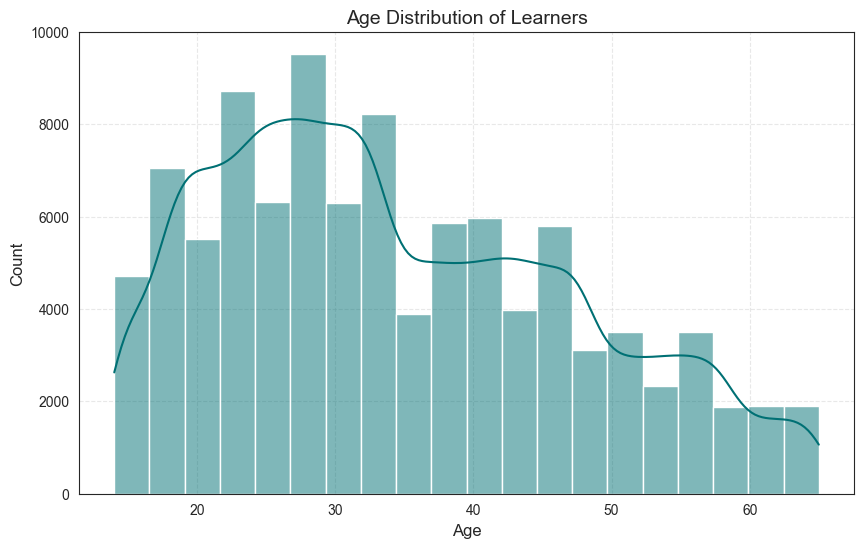

In [18]:
sns.histplot(df['age'], kde=True, color=teal, bins=20) 
plt.title('Age Distribution of Learners')
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(True, color=light_grey, linestyle='--', alpha=0.6)
plt.show()

In [19]:
# Gender Distribution of Learners
# Gender Split (Donut Chart)
# pandas, plotly.express

In [20]:
# Count gender values
gender_counts = df['gender'].value_counts()

# Create donut chart
fig = px.pie(
    values=gender_counts.values,
    names=gender_counts.index,
    hole=0.7,   # Creates donut effect
    title='Gender Distribution of Learners',  
    color_discrete_sequence=[teal, yellow, dark_green, black])

# Customize text and layout
fig.update_traces(
    textposition='outside',
    textinfo='percent+label')

fig.update_layout(
    width=900,
    height=600,

    plot_bgcolor = white,
    paper_bgcolor = white,
    title_x=0.5)

fig.show()

# fig.write_image("chart.png")

In [21]:
# Top 10 Countries by learner count. This identifies your primary markets.
# Bar Chart 
# pandas, matplotlib


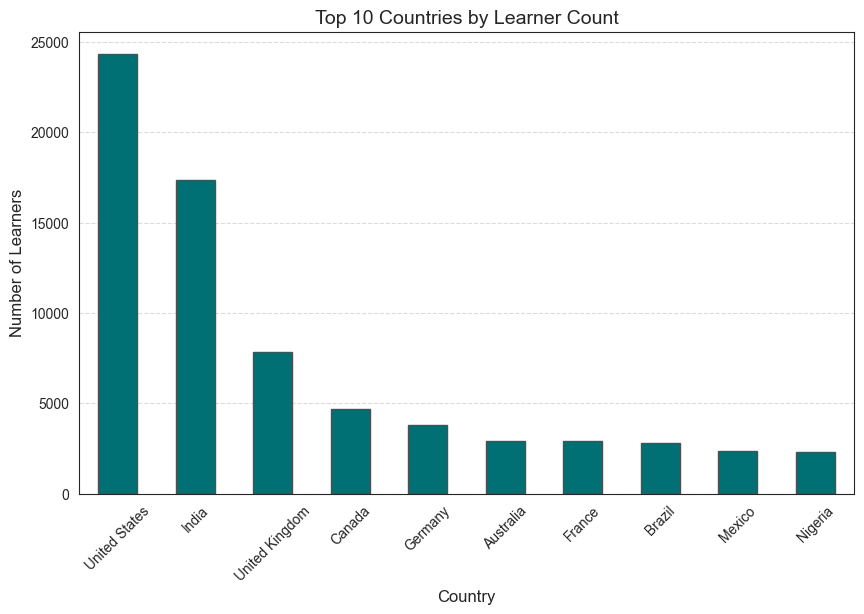

In [22]:
top_countries = df['country'].value_counts().head(10)

top_countries.plot(kind='bar', color= teal, edgecolor= dark_grey)

plt.title('Top 10 Countries by Learner Count')
plt.xlabel('Country')
plt.ylabel('Number of Learners')
plt.xticks(rotation=45) # Rotates country names for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [23]:
# Education Levels across MOOC Platforms
# See if specific platforms attract more highly educated learners (e.g., Graduates vs. High Schoolers)
# Count Plot
# Seaborn

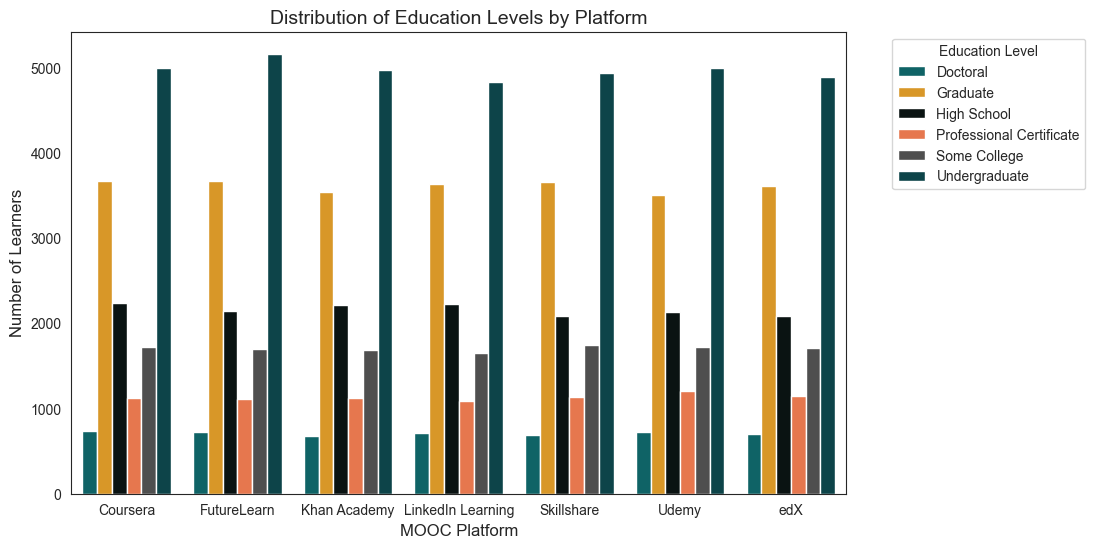

In [24]:
sns.countplot(data=df, x='mooc_platform', hue='education_level', 
              palette=[teal, yellow, black, orange, dark_grey, dark_teal])

plt.title('Distribution of Education Levels by Platform')
plt.xlabel('MOOC Platform')
plt.ylabel('Number of Learners')
plt.legend(title='Education Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Analyze factors driving online course completion

In [25]:
# Monthly Course Completion Trend
# How have course completion trends evolved over time?

In [26]:
# FEATURE ENGINEERING
# Create month column from enrollment date.

df['month'] = (df['enrollment_date'].dt.to_period('M').astype(str))

In [27]:
# AGGREGATE MONTHLY COMPLETION RATE

monthly_completion = (df.groupby('month')['course_completed'].mean().reset_index())
monthly_completion['course_completed'] *= 100

In [28]:
# CREATE TREND LINE CHART
# PYTHON CODE (PLOTLY)

fig = px.line(monthly_completion, x='month', y='course_completed', markers=True, title='Monthly Course Completion Trend')

fig.update_traces( line_color=dark_teal, marker_color= yellow)

fig.update_layout( plot_bgcolor=white, paper_bgcolor=white,
    title_font_size=17,
    xaxis_title='Month',
    yaxis_title='Completion Rate (%)',
    xaxis=dict(gridcolor= '#B2B2B2'),
    yaxis=dict(gridcolor= '#B2B2B2'))

fig.show()

# fig.write_image("chart.png")

In [29]:
# Course Category Vs Course Completion
# which course categories contribute most to completed learners
# TreeMap
# Plotly

In [30]:
# CREATE AGGREGATED DATA
course_completion = (df.groupby('course_category')['course_completed'].sum().reset_index())

course_completion.columns = ['course_category','completed_learners']

In [31]:
fig = px.treemap(course_completion,
                 path=['course_category'],
                 values='completed_learners',
                 color='completed_learners',
                 color_continuous_scale=[
                     yellow,
                     teal,
                     dark_teal],
                title='Course Category Contribution to Completion')

fig.update_layout(
    paper_bgcolor=white,
    title_font_size = 17,
    font=dict(size=14))

fig.show()

# fig.write_image("chart.png")

In [32]:
# Engagement factors driving course completion
# Correlation Heatmap
# Seaborn, Matplotlib

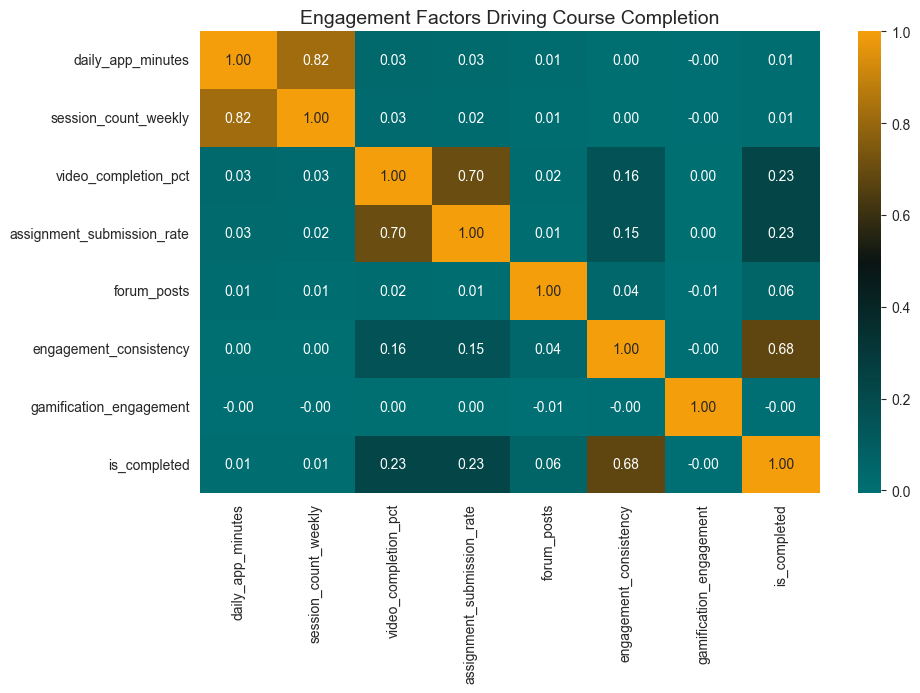

In [33]:
df['is_completed'] = df['course_completed'].astype(int)

features = [
    'daily_app_minutes','session_count_weekly','video_completion_pct',
    'assignment_submission_rate','forum_posts','engagement_consistency',
    'gamification_engagement','is_completed']

# Custom color palette
custom_cmap = LinearSegmentedColormap.from_list(
    'custom_teal',
    [ teal,black,yellow]
)

corr = df[features].corr()

sns.heatmap(corr, annot=True, cmap=custom_cmap, fmt= '.2f')
plt.title('Engagement Factors Driving Course Completion')
plt.show()

In [34]:
# Course Completion Rate 
# What is the overall course completion rate?
# Gauge Chart 
# Plotly

In [35]:
completion_rate = (df['course_completed'].mean() * 100)

fig = go.Figure(go.Indicator(
    mode="gauge+number",
    value=completion_rate,
    title={'text': "Global Course Completion Rate (%)"},
    gauge={'axis': {'range': [0,100]},
          'bar': {'color': orange},
          'steps': [{'range': [0,40], 'color': yellow},
                   {'range': [40,70], 'color': teal},
                   {'range': [70,100], 'color': dark_teal}]}))

fig.show()

# fig.write_image("chart.png")

Digital Literacy Impact on Learner Outcomes

In [36]:
# Digital literacy lmpact on learning outcomes
# Side by Side Boxplot  
# Seaborn , Matplotlib


In [37]:
# Defining the Literacy Tiers
df['literacy_tier'] = pd.cut(df['digital_literacy_score'], bins=3, 
                             labels=['Beginner', 'Intermediate', 'Advanced'])

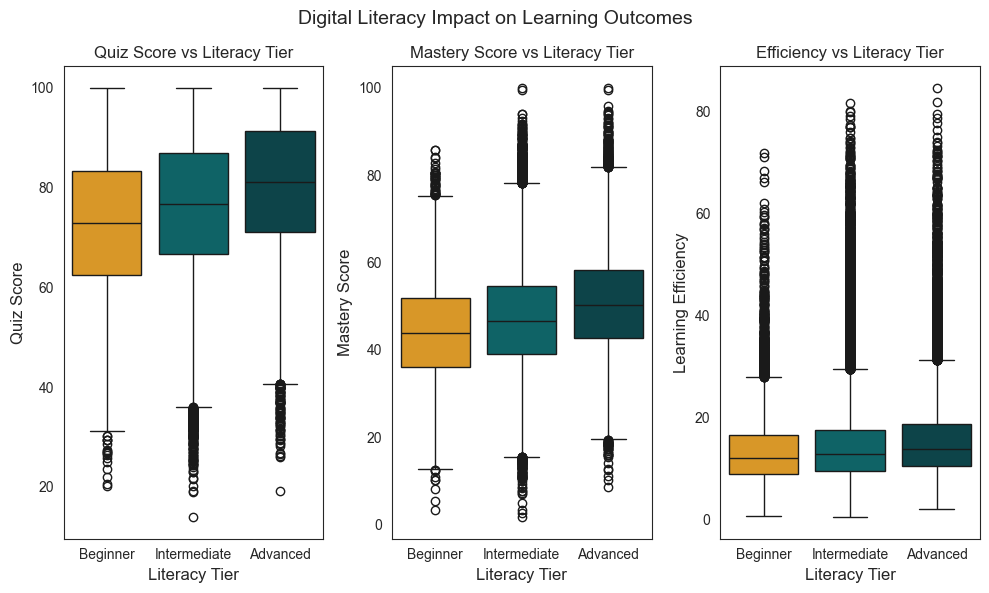

In [38]:
fig, axes = plt.subplots(1, 3,figsize=(10,6))

# -----------------------------
# Plot 1 — Quiz Score
# -----------------------------

sns.boxplot(
    data=df,
    x='literacy_tier',
    y='in_app_quiz_score',
    ax=axes[0],
    palette=[yellow, teal, dark_teal])
axes[0].set_title('Quiz Score vs Literacy Tier',fontsize = 12)
axes[0].set_xlabel('Literacy Tier')
axes[0].set_ylabel('Quiz Score')


# -----------------------------
# Plot 2 — Mastery Score
# -----------------------------

sns.boxplot(
    data=df,
    x='literacy_tier',
    y='mastery_score',
    ax=axes[1],
    palette=[yellow, teal, dark_teal])
axes[1].set_title('Mastery Score vs Literacy Tier',fontsize = 12)
axes[1].set_xlabel('Literacy Tier')
axes[1].set_ylabel('Mastery Score')


# -----------------------------
# Plot 3 — Learning Efficiency
# -----------------------------

sns.boxplot(
    data=df,
    x='literacy_tier',
    y='learning_efficiency_score',
    ax=axes[2],
    palette=[yellow, teal, dark_teal])
axes[2].set_title('Efficiency vs Literacy Tier', fontsize = 12)
axes[2].set_xlabel('Literacy Tier')
axes[2].set_ylabel('Learning Efficiency')


# -----------------------------
# Main Layout
# -----------------------------

plt.suptitle('Digital Literacy Impact on Learning Outcomes',fontsize=14)

plt.tight_layout()
plt.show()

In [39]:
# Literacy → Completion → Learning Path
# Show how literacy level influences: completion & learning path effectiveness
# Sunburst Chart
# Plotly

In [40]:
df['count'] = 1

fig = px.sunburst(
    df,
    path=['literacy_tier', 'course_completed','learning_path_type'],
    values='count',
    color='literacy_tier',
    color_discrete_sequence=[yellow, teal, dark_teal],
    title='Digital Literacy → Completion → Learning Path')

fig.show()

# fig.write_image("chart.png")

In [41]:
# Engagement profile by literacy level
# How do engagement behaviors differ between Low/Medium/High literacy groups?
# Radar Chart
# Matplotlib

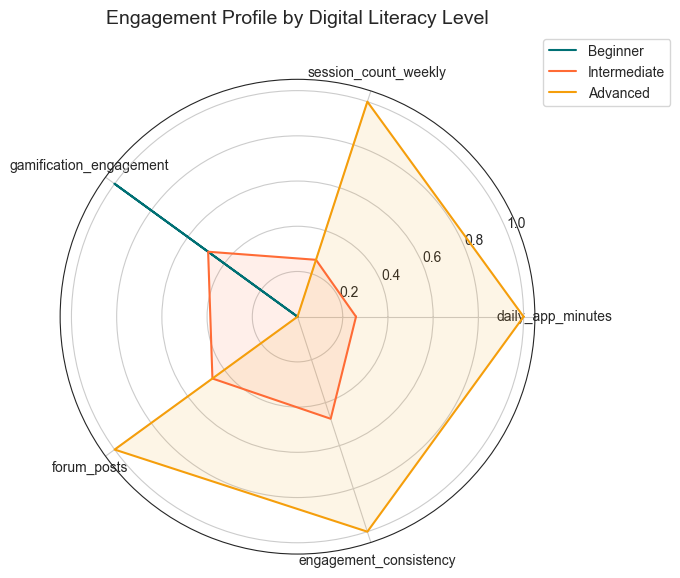

In [42]:
radar_features = ['daily_app_minutes', 'session_count_weekly',
                  'gamification_engagement', 'forum_posts', 'engagement_consistency']

radar_df = df.groupby('literacy_tier')[radar_features].mean()

# Normalize 0–1 for radar
radar_norm = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min())

labels = radar_features
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # close the loop

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for level in radar_norm.index:
    values = radar_norm.loc[level].tolist()
    values += values[:1]
    ax.plot(angles, values, label=str(level))
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10)
ax.set_title('Engagement Profile by Digital Literacy Level', y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

Study Different Learning Path Effectiveness

In [43]:
# Completion by Learning Path
# To Determine which learning path type result in more completions.
# Pie Chart
# Matplotlib 

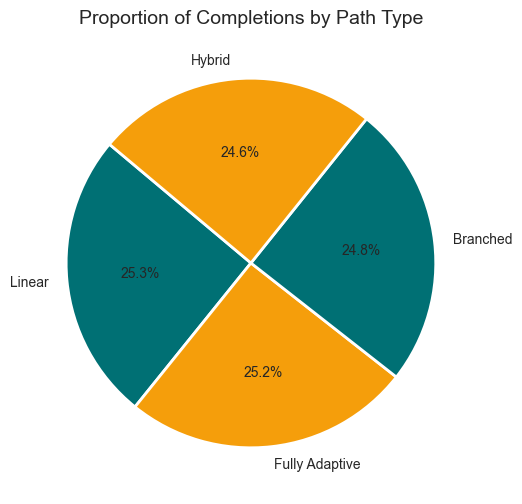

In [44]:
# Filtering for only completed courses
completed_df = df[df['course_completed'] == True]
path_counts = completed_df['learning_path_type'].value_counts()

plt.pie(path_counts, labels=path_counts.index, autopct='%1.1f%%', 
        colors=[teal, yellow], startangle=140, 
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})

plt.title('Proportion of Completions by Path Type')
plt.show()

In [45]:
# Time to Mastery by Learning path
# Bar Chart
# Seaborn, Matplotlib

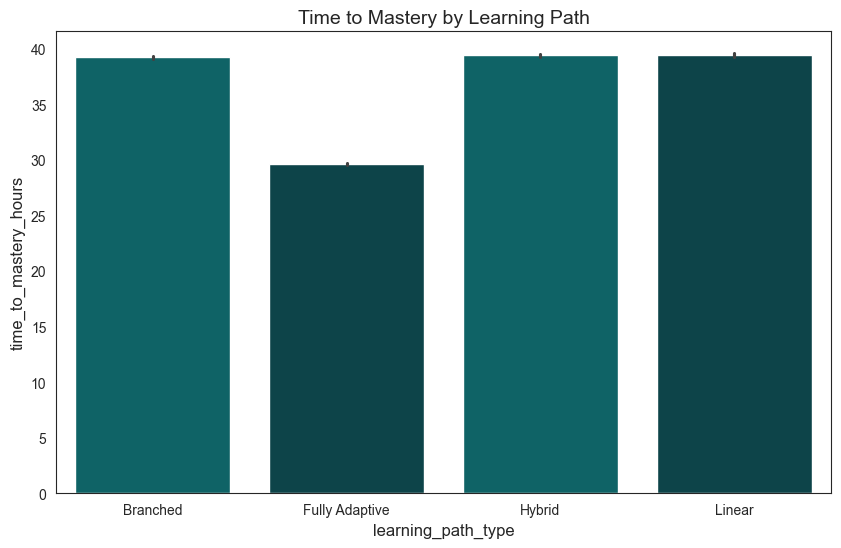

In [46]:
sns.barplot(
    data=df,
    x='learning_path_type',
    y='time_to_mastery_hours',
    palette=[teal, dark_teal])

plt.title('Time to Mastery by Learning Path')

plt.show()

In [47]:
# Mastery Score & Path Type
# Compare the statistical "Mastery" reliability of different paths.
# Point Plot
# Seaborn 

In [48]:
# Success Label
df['Status'] = df['course_completed'].map({True: 'Completed', False: 'Dropped'})

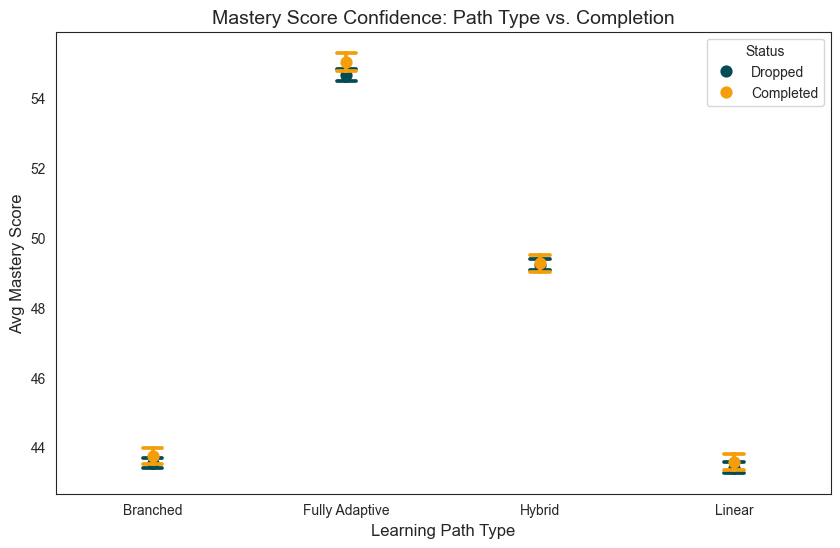

In [49]:
plt.figure(figsize=(10, 6))
sns.pointplot(data=df, x='learning_path_type', y='mastery_score', 
              hue='Status', palette=[dark_teal,yellow], join=False, capsize=.1)

plt.title('Mastery Score Confidence: Path Type vs. Completion', fontsize=14)
plt.ylabel('Avg Mastery Score')
plt.xlabel('Learning Path Type')
plt.show()

In [50]:
# Skill Gain by Learning Path Type
# Which learning path drives better skill improvement?
# Boxplot
# Seaborn, Matplotlib

In [51]:
df['skill_improvement'] = (df['skill_post_score'] -df['skill_pre_score'])

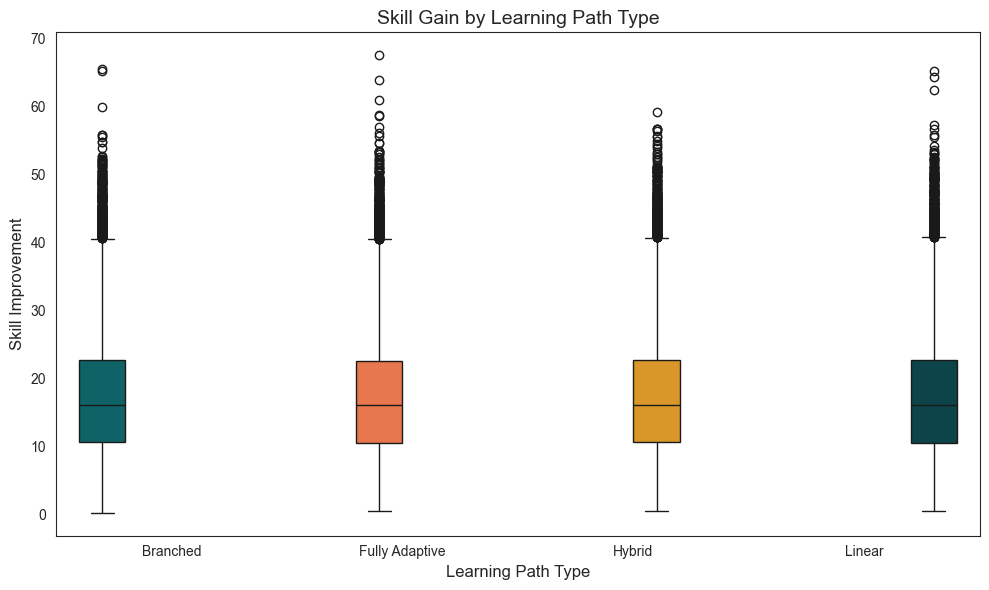

In [52]:
sns.boxplot(
    data=df,
    x='learning_path_type',
    y='skill_improvement',
    hue='learning_path_type',
    legend=False)

plt.title('Skill Gain by Learning Path Type')

plt.xlabel('Learning Path Type')
plt.ylabel('Skill Improvement')

plt.tight_layout()
plt.show()

In [53]:
# Correlation of Learning Path Effectiveness Metrics
# Compare how each path influences multiple outcomes.
# Heatmap
# Seaborn

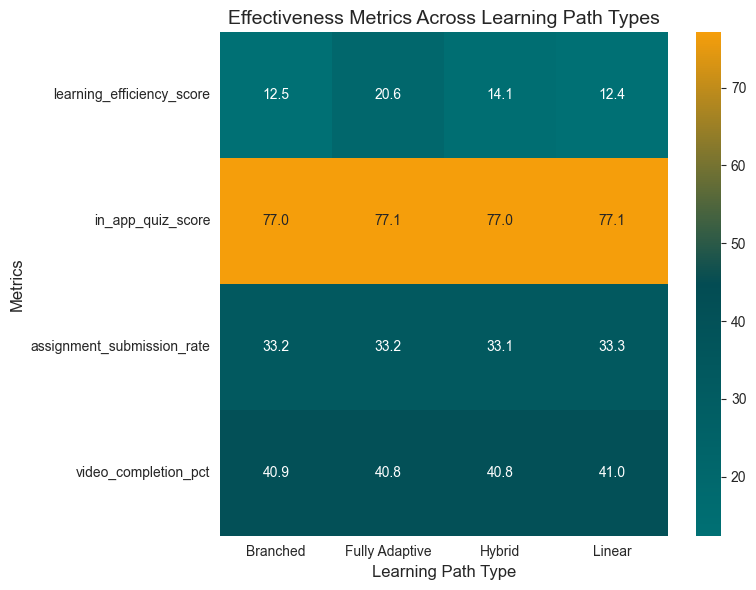

In [54]:
metrics = ['learning_efficiency_score',
           'in_app_quiz_score','assignment_submission_rate',
           'video_completion_pct']

# Custom color palette
custom_cmap = LinearSegmentedColormap.from_list('custom_teal',[ teal,dark_teal,yellow])

corr_df = df.groupby('learning_path_type')[metrics].mean().T

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_df,
    annot=True,
    cmap=custom_cmap,
    fmt='.1f'
)
plt.title('Effectiveness Metrics Across Learning Path Types')
plt.ylabel('Metrics')
plt.xlabel('Learning Path Type')
plt.tight_layout()
plt.show()

In [55]:
# KEY INSIGHTS
# Learner demographics show a young, globally diverse audience
# Course completion rates are relatively low
# Course completion is strongly driven by engagement intensity
# Technical and Career-Oriented Courses Drive Higher Completion
# Digital literacy has a major impact on learning outcomes
# Adaptive learning paths perform better than traditional models


In [56]:
# RECOMMENDATIONS
# Improve Course Completion and Retention
# Strengthen early‑stage engagement
# Provide targeted support for low‑literacy learners.
# Personalize learning experiences based on learner profiles.
# Expand High-Demand Course Categories
# Invest in Adaptive Learning Technologies
